<a href="https://colab.research.google.com/github/melissacotton36618-dev/DHS-8555/blob/main/3_DHS_8555.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=5371da9f9745fca5375427524b22de914f49a27a6565c164da6f48bd10d9a7de
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data

# Load the data
Auto = load_data("Auto")

# Define predictor and response
X = sm.add_constant(Auto["horsepower"])
y = Auto["mpg"]

# Fit the regression model
model = sm.OLS(y, X).fit()

# Display the regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           7.03e-81
Time:                        03:44:41   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

In [ ]:
new = pd.DataFrame({"const": [1], "horsepower": [98]})

prediction = model.get_prediction(new)

print(prediction.summary_frame(alpha=0.05))

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      23.973079      24.961075     14.809396   

   obs_ci_upper  
0     34.124758  


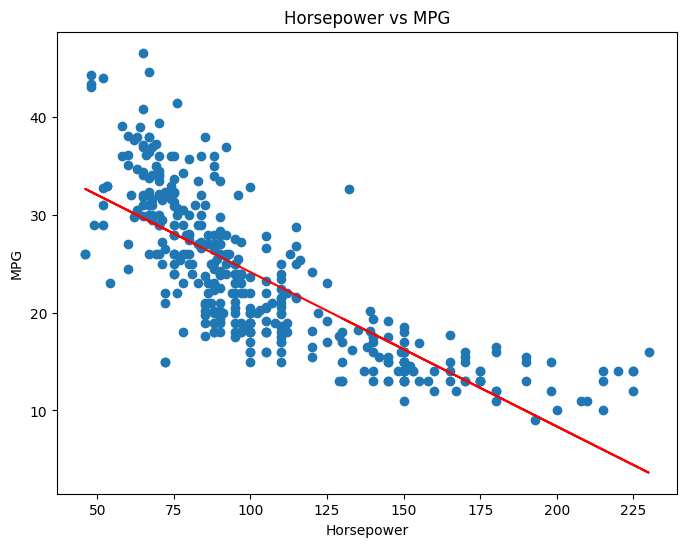

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(Auto["horsepower"], Auto["mpg"])

x = Auto["horsepower"]
yhat = model.predict(X)

ax.plot(x, yhat, color="red")

ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("Horsepower vs MPG")

plt.show()

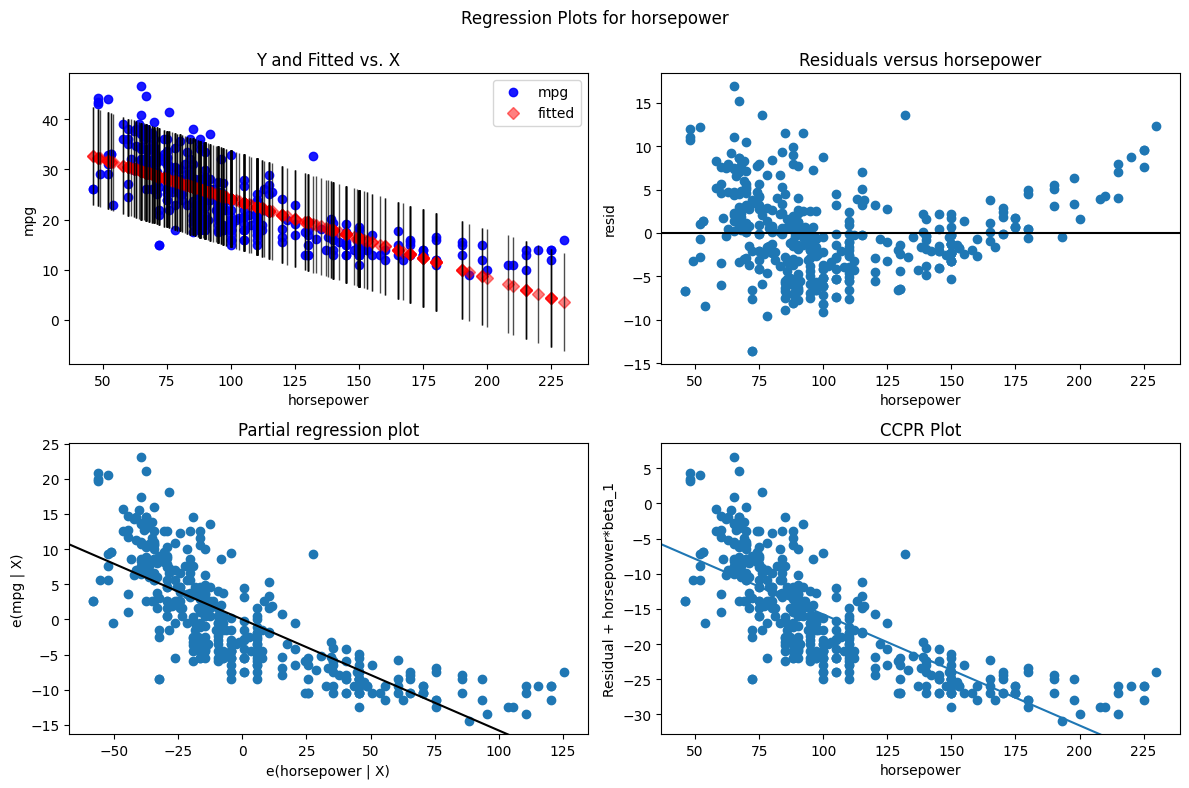

In [ ]:
fig = plt.figure(figsize=(12,8))

fig = sm.graphics.plot_regress_exog(model, "horsepower", fig=fig)

plt.show()

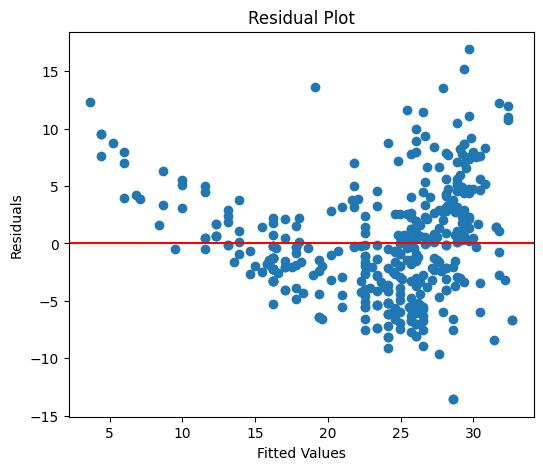

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color="red")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

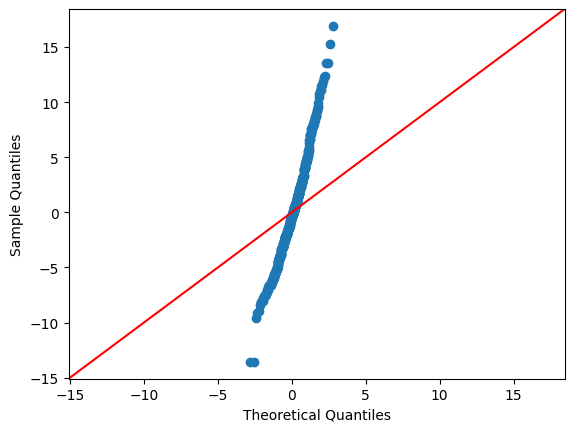

In [ ]:
sm.qqplot(model.resid, line="45")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Separate predictors and response
X = carseats.drop("Sales", axis=1)
y = carseats["Sales"]

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge model
ridge_model = Ridge(alpha=1)

ridge_model.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_valid)

print("Ridge model completed!")

Ridge model completed!


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv"

carseats = pd.read_csv(url)

carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [4]:
X = carseats.drop("Sales", axis=1)
y = carseats["Sales"]

In [6]:
X = pd.get_dummies(X, drop_first=True)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.model_selection import train_test_split

# Define predictors and target
X = carseats.drop("Sales", axis=1)
y = carseats["Sales"]

# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(320, 10)
(80, 10)


In [11]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3,3,50)))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_valid)

ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_pred))

print("Best alpha:", ridge_model.named_steps["ridge"].alpha_)
print("Validation RMSE:", ridge_rmse)

Best alpha: 0.49417133613238334
Validation RMSE: 1.0467435331372552


In [12]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# PCR model
pcr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("regression", LinearRegression())
])

# Fit PCR model
pcr_model.fit(X_train, y_train)

# Predictions
pcr_pred = pcr_model.predict(X_valid)

# Calculate RMSE
pcr_rmse = np.sqrt(mean_squared_error(y_valid, pcr_pred))

print("PCR Validation RMSE:", pcr_rmse)

PCR Validation RMSE: 1.0468017357559338


In [13]:
for n in range(1, X_train.shape[1] + 1):
    pcr = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("regression", LinearRegression())
    ])

    scores = cross_val_score(
        pcr,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    rmse = np.sqrt(-scores.mean())

    print("Components:", n, "RMSE:", rmse)

Components: 1 RMSE: 2.6005067018676282
Components: 2 RMSE: 2.5348925559723883
Components: 3 RMSE: 2.5042791985118837
Components: 4 RMSE: 2.5207005863691423
Components: 5 RMSE: 2.505808156851816
Components: 6 RMSE: 2.536991784111511
Components: 7 RMSE: 2.506263266452619
Components: 8 RMSE: 2.5076374536243358
Components: 9 RMSE: 2.185247625709481
Components: 10 RMSE: 1.0972026589386812
Components: 11 RMSE: 1.0359898311386315


In [15]:
submission = pd.DataFrame({
    "id": test_ids,
    "Rings": predictions
})

submission.to_csv("submission.csv", index=False)

NameError: name 'test_ids' is not defined

In [17]:
%whos

Variable             Type         Data/Info
-------------------------------------------
LinearRegression     ABCMeta      <class 'sklearn.linear_mo<...>._base.LinearRegression'>
PCA                  ABCMeta      <class 'sklearn.decomposition._pca.PCA'>
Pipeline             ABCMeta      <class 'sklearn.pipeline.Pipeline'>
Ridge                ABCMeta      <class 'sklearn.linear_model._ridge.Ridge'>
RidgeCV              ABCMeta      <class 'sklearn.linear_model._ridge.RidgeCV'>
StandardScaler       type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                    DataFrame         CompPrice  Income  A<...>\n[400 rows x 11 columns]
X_train              DataFrame         CompPrice  Income  A<...>\n[320 rows x 11 columns]
X_valid              DataFrame         CompPrice  Income  A<...>n\n[80 rows x 11 columns]
carseats             DataFrame         Sales  CompPrice  In<...>\n[400 rows x 11 columns]
cross_val_score      function     <function cross_val_score at 0x7a2a

In [22]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.head())
print(test.head())

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [32]:
import os

os.listdir()

['.config', 'sample_submission.csv', 'test.csv', 'sample_data']

In [36]:
!ls -lah /content

total 3.6M
drwxr-xr-x 1 root root 4.0K Aug  3 04:40 .
drwxr-xr-x 1 root root 4.0K Aug  3 04:54 ..
drwxr-xr-x 4 root root 4.0K Jun  4 13:32 .config
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 581K Aug  3 04:40 sample_submission.csv
-rw-r--r-- 1 root root 3.0M Aug  3 04:40 test.csv


In [38]:
import os
os.listdir()

['.config', 'sample_submission.csv', 'test.csv', 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [39]:
import zipfile
import os

zip_path = "/train.csv (2).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

os.listdir("/content")

['.config', 'sample_submission.csv', 'train.csv', 'test.csv', 'sample_data']

In [40]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [41]:
train.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings'],
      dtype='object')

In [42]:
train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [43]:
train.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings'],
      dtype='object')

In [44]:
import pandas as pd
import numpy as np

# Separate target
X = train.drop("Rings", axis=1)
y = train["Rings"]

# Remove ID column
X = X.drop("id", axis=1)

# Convert categorical variable
X = pd.get_dummies(X, drop_first=True)

# Prepare test data
test_features = test.drop("id", axis=1)
test_features = pd.get_dummies(test_features, drop_first=True)

# Make sure train and test have same columns
test_features = test_features.reindex(columns=X.columns, fill_value=0)

print(X.shape)
print(test_features.shape)

(90615, 9)
(60411, 9)


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3,3,50)))
])

ridge_model.fit(X, y)

ridge_predictions = ridge_model.predict(test_features)

print("Best Alpha:", ridge_model.named_steps["ridge"].alpha_)

Best Alpha: 2.6826957952797246


In [46]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

pcr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("regression", LinearRegression())
])

pcr_model.fit(X, y)

pcr_predictions = pcr_model.predict(test_features)

print("Number of components:",
      pcr_model.named_steps["pca"].n_components_)

Number of components: 3


In [49]:
submission = pd.DataFrame({
    "id": test["id"],
    "Rings": ridge_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,Rings
0,90615,8.537153
1,90616,10.030548
2,90617,10.305966
3,90618,10.955544
4,90619,7.782764


In [50]:
import os
os.listdir("/content")

['.config',
 'submission.csv',
 'sample_submission.csv',
 'train.csv',
 'test.csv',
 'sample_data']

In [53]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "submission" in file.lower():
            print(os.path.join(root, file))


/content/submission.csv
/content/sample_submission.csv


In [55]:
# Remove negative predictions
ridge_predictions_fixed = np.maximum(ridge_predictions, 0)

submission = pd.DataFrame({
    "id": test["id"],
    "Rings": ridge_predictions_fixed
})

submission.to_csv("/content/submission.csv", index=False)

submission.head()

,id,Rings
0,90615,8.537153
1,90616,10.030548
2,90617,10.305966
3,90618,10.955544
4,90619,7.782764


In [56]:
submission["Rings"].min()

0.0

In [57]:
from google.colab import files

files.download('/content/submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>